##  Google Colab Setup

### ES

Si ejecutas este notebook en Google Colab, monta tu Google Drive y sitúate en la raíz del proyecto (mismo nivel que `data/` y `models/`), tal y como hace `03_model_selection_and_training.ipynb`.

### EN

If you run this notebook on Google Colab, mount your Google Drive and move to the project root (same level as `data/` and `models/`), just like `03_model_selection_and_training.ipynb` does.


In [2]:
    # ES: Descomenta y ejecuta esta celda solo si trabajas en Google Colab.
    # EN: Uncomment and run this cell only if you are working on Google Colab.

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/SyntaxRelax/

Mounted at /content/drive
/content/drive/MyDrive/SyntaxRelax


# 04 - Model Evaluation and Metrics

## ES | Objetivo

Este notebook realiza la evaluación final, desde el rol de QA (Miembro 4), del modelo entrenado y seleccionado en `03_model_selection_and_training.ipynb`.

Se incluye:

- Carga del modelo final (`XGBoost`) y de los conjuntos de entrenamiento y test.
- Métricas de clasificación (Accuracy, Precision, Recall, F1-score) en train y test.
- Comprobación explícita de overfitting.
- Matriz de confusión (absoluta y normalizada) con estilo visual profesional.
- Curvas ROC y Precision-Recall por clase (One-vs-Rest).
- Importancia de variables (*feature importance*) del modelo XGBoost.
- Checklist de calidad orientado al riesgo de negocio.
- Borrador de la sección "Resultados del Modelo" para el `README.md`.

---

## EN | Goal

This notebook carries out the final evaluation, from the QA role (Member 4), of the model trained and selected in `03_model_selection_and_training.ipynb`.

It includes:

- Loading the final model (`XGBoost`) and the train/test sets.
- Classification metrics (Accuracy, Precision, Recall, F1-score) on train and test.
- An explicit overfitting check.
- The confusion matrix (absolute and normalized) with a professional visual style.
- ROC and Precision-Recall curves per class (One-vs-Rest).
- Feature importance from the XGBoost model.
- A business-risk-oriented quality checklist.
- A draft of the "Model Results" section for the `README.md`.


# Test Notebook 02

## 0. Sanity Check - Preprocessing Pipeline (from Notebook 02)

### ES

Antes de evaluar el modelo, verificamos que el pipeline de preprocesado guardado por Miembro 2 en `02_data_preprocessing_and_engineering.ipynb` (`preprocessing_pipeline.joblib`) sigue funcionando correctamente de forma aislada, reproduciendo la función `clean_and_process(raw_dict)` y probándola con un ejemplo simulado.

### EN

Before evaluating the model, we verify that the preprocessing pipeline saved by Member 2 in `02_data_preprocessing_and_engineering.ipynb` (`preprocessing_pipeline.joblib`) still works correctly in isolation, reproducing the `clean_and_process(raw_dict)` function and testing it with a simulated example.


### Load the Fitted Preprocessing Pipeline

#### ES

Cargamos el pipeline de preprocesado ya ajustado y sus metadatos, guardados por Miembro 2 en el notebook 02. Esto simula cómo lo haría `app.py` (Miembro 5) en producción.

#### EN

We load the already-fitted preprocessing pipeline and its metadata, saved by Member 2 in notebook 02. This simulates how `app.py` (Member 5) would do it in production.


In [3]:
import pandas as pd
import joblib
import json

_fitted_pipeline = joblib.load("./models/preprocessing_pipeline.joblib")

with open("./models/preprocessing_metadata.json") as f:
    _metadata = json.load(f)

_expected_columns = _metadata["categorical_features"] + _metadata["numerical_features"]

print("Expected input columns:", _expected_columns)


Expected input columns: ['day_type', 'work_hours', 'screen_time_hours', 'meetings_count', 'breaks_taken', 'after_hours_work', 'app_switches', 'sleep_hours', 'task_completion', 'isolation_index', 'fatigue_score']


### `clean_and_process(raw_dict)` Function

#### ES

Reproducimos aquí la función `clean_and_process`, tal y como se define en `02_data_preprocessing_and_engineering.ipynb` y en `src/preprocessing.py`, para poder probarla de forma aislada.

#### EN

We reproduce the `clean_and_process` function here, exactly as defined in `02_data_preprocessing_and_engineering.ipynb` and in `src/preprocessing.py`, so it can be tested in isolation.


In [6]:
def clean_and_process(raw_dict, pipeline=_fitted_pipeline, expected_columns=_expected_columns):
    """
    ES: Transforma un diccionario de entrada (por ejemplo, procedente de un
    formulario HTML) en un array listo para el modelo de riesgo de burnout.

    EN: Transforms an input dictionary (e.g. coming from an HTML form)
    into an array ready for the burnout risk model.

    Parameters
    ----------
    raw_dict : dict
        ES: Diccionario con las claves: day_type, work_hours, screen_time_hours,
        meetings_count, breaks_taken, after_hours_work, app_switches,
        sleep_hours, task_completion, isolation_index, fatigue_score.
        EN: Dictionary with keys: day_type, work_hours, screen_time_hours,
        meetings_count, breaks_taken, after_hours_work, app_switches,
        sleep_hours, task_completion, isolation_index, fatigue_score.

    Returns
    -------
    numpy.ndarray
        ES: Array 2D (1 fila) listo para pasar a predict_attrition().
        EN: 2D array (1 row) ready to be passed to predict_attrition().
    """

    # ES: Comprobar que no falte ninguna clave esperada.
    # EN: Check that no expected key is missing.

    missing_keys = [column for column in expected_columns if column not in raw_dict]
    if missing_keys:
        raise ValueError(f"Missing keys in raw_dict: {missing_keys}")

    # ES: Construir un DataFrame de una fila con el orden de columnas correcto.
    # EN: Build a single-row DataFrame with the correct column order.

    input_df = pd.DataFrame([{column: raw_dict[column] for column in expected_columns}])

    # ES: Aplicar el pipeline de preprocesado ya ajustado.
    # EN: Apply the already-fitted preprocessing pipeline.

    processed_array = pipeline.transform(input_df)

    return processed_array


### Testing the Function

#### ES

Probamos la función con un ejemplo simulado, similar al que llegaría desde el formulario web: un puesto con jornada larga, poco descanso y alta fatiga (perfil de riesgo esperado: medio/alto).

#### EN

We test the function with a simulated example, similar to what would arrive from the web form: a job profile with long working hours, little rest and high fatigue (expected risk profile: medium/high).


In [5]:
sample_raw_dict = {
    "day_type": "Weekday",
    "work_hours": 11.5,
    "screen_time_hours": 10.2,
    "meetings_count": 5,
    "breaks_taken": 2,
    "after_hours_work": 1,
    "app_switches": 95,
    "sleep_hours": 5.2,
    "task_completion": 68.0,
    "isolation_index": 7,
    "fatigue_score": 8.6,
}

processed_sample = clean_and_process(sample_raw_dict)

print("Processed array shape:", processed_sample.shape)
print(processed_sample)


Processed array shape: (1, 11)
[[ 0.          1.47111     1.25694751  0.45097387 -1.71333312  2.34607439
   1.62773544 -1.72901068 -0.93982067  1.27037338  0.92324613]]


#### Interpretation

##### ES

El array resultante confirma que el pipeline guardado en el notebook 02 se carga y aplica correctamente fuera de ese notebook: la variable categórica `day_type` se codifica y las variables numéricas quedan escaladas, con la misma forma que los conjuntos de entrenamiento/test procesados.

Esto valida, desde el rol de QA, que el artefacto (`preprocessing_pipeline.joblib`) es reutilizable de forma independiente por el resto del equipo (por ejemplo, por Miembro 5 desde `app.py`), antes de pasar a la evaluación completa del modelo final.

##### EN

The resulting array confirms that the pipeline saved in notebook 02 loads and applies correctly outside that notebook: the categorical variable `day_type` is encoded and the numerical variables are scaled, with the same shape as the processed train/test sets.

This validates, from the QA role, that the artifact (`preprocessing_pipeline.joblib`) can be reused independently by the rest of the team (e.g. by Member 5 from `app.py`), before moving on to the full evaluation of the final model.


# Test Notebook 03

## 2. Environment Setup and Imports

### ES

Cargamos las librerías necesarias: `pandas`/`numpy` para datos, `joblib` para cargar el modelo, `matplotlib`/`seaborn` para las visualizaciones, y los módulos de métricas y `OrdinalEncoder` de `scikit-learn` (necesario para recuperar el mismo mapeo de clases usado en el notebook 03).

### EN

We load the required libraries: `pandas`/`numpy` for data, `joblib` to load the model, `matplotlib`/`seaborn` for the visualizations, and the metrics modules and `OrdinalEncoder` from `scikit-learn` (needed to recover the same class mapping used in notebook 03).


In [7]:
import numpy as np
import pandas as pd
import joblib

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc,
    precision_recall_curve,
)
from sklearn.preprocessing import label_binarize

pd.set_option("display.max_columns", None)

# ES: Paleta corporativa consistente con el notebook 03, con un esquema tipo
# "semáforo" (verde / ámbar / rojo) para las clases de riesgo.
# EN: Corporate palette consistent with notebook 03, using a "traffic light"
# scheme (green / amber / red) for the risk classes.

PALETTE = {
    "Low": "#10B981",
    "Medium": "#F59E0B",
    "High": "#EF4444",
    "primary": "#1f4e79",
    "secondary": "#10B981",
}

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams["axes.edgecolor"] = "#4B5563"
plt.rcParams["axes.titleweight"] = "bold"

RANDOM_STATE = 42


## 3. Load Model and Data

### ES

Cargamos el modelo final (`XGBoost`, serializado por Miembro 3) y los conjuntos de datos preprocesados. Reconstruimos el mismo `OrdinalEncoder` jerárquico (`Low` → 0, `Medium` → 1, `High` → 2) utilizado durante el entrenamiento, para poder decodificar las predicciones a etiquetas legibles.

### EN

We load the final model (`XGBoost`, serialized by Member 3) and the preprocessed datasets. We rebuild the same hierarchical `OrdinalEncoder` (`Low` → 0, `Medium` → 1, `High` → 2) used during training, so predictions can be decoded back into readable labels.


In [8]:
# ES: Cargar el modelo final.
# EN: Load the final model.

model_path = "./models/best_burnout_model.joblib"
model = joblib.load(model_path)

print(f"Model loaded: {type(model).__name__}")

# ES: Cargar los datos preprocesados.
# EN: Load the preprocessed data.

data_path = "./data/processed/burnout_processed.npz"

with np.load(data_path, allow_pickle=True) as data:
    X_train = data["X_train.npy"]
    X_test = data["X_test.npy"]
    y_train = data["y_train.npy"]
    y_test = data["y_test.npy"]

# ES: Reconstruir el mismo orden jerárquico usado en el notebook 03.
# EN: Rebuild the same hierarchical order used in notebook 03.

custom_order = ["Low", "Medium", "High"]
ordinal_encoder = OrdinalEncoder(categories=[custom_order])

y_train_encoded = ordinal_encoder.fit_transform(y_train.reshape(-1, 1)).ravel().astype(int)
y_test_encoded = ordinal_encoder.transform(y_test.reshape(-1, 1)).ravel().astype(int)

class_labels = custom_order
label_to_name = dict(enumerate(class_labels))

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Classes: {class_labels}")


Model loaded: XGBClassifier
X_train: (1600, 11)  |  X_test: (400, 11)
Classes: ['Low', 'Medium', 'High']


## 4. Predictions on Train and Test

### ES

Generamos las predicciones (etiqueta y probabilidad) del modelo tanto en el conjunto de entrenamiento como en el de test.

### EN

We generate the model's predictions (label and probability) on both the training and test sets.


In [9]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

y_train_proba = model.predict_proba(X_train)
y_test_proba = model.predict_proba(X_test)

print("Predictions generated for both train and test sets.")


Predictions generated for both train and test sets.


## 5. Classification Metrics

### ES

Calculamos *Accuracy*, *Precision*, *Recall* y *F1-score* (promedio macro) en entrenamiento y test. El promedio **macro** es especialmente importante aquí, dado que la clase `High` representa solo ~7% de los datos.

### EN

We compute Accuracy, Precision, Recall and F1-score (macro average) on training and test. The **macro** average is especially important here, given that the `High` class represents only ~7% of the data.


In [10]:
metrics_summary = pd.DataFrame({
    "Train": {
        "Accuracy": accuracy_score(y_train_encoded, y_train_pred),
        "Precision (macro)": precision_score(y_train_encoded, y_train_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_train_encoded, y_train_pred, average="macro", zero_division=0),
        "F1-score (macro)": f1_score(y_train_encoded, y_train_pred, average="macro", zero_division=0),
    },
    "Test": {
        "Accuracy": accuracy_score(y_test_encoded, y_test_pred),
        "Precision (macro)": precision_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
        "Recall (macro)": recall_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
        "F1-score (macro)": f1_score(y_test_encoded, y_test_pred, average="macro", zero_division=0),
    },
}).round(4)

metrics_summary["Gap (Train - Test)"] = (metrics_summary["Train"] - metrics_summary["Test"]).round(4)

display(metrics_summary.style.background_gradient(cmap="Blues", subset=["Train", "Test"]).format("{:.4f}"))


,Train,Test,Gap (Train - Test)
Accuracy,1.0000,0.9875,0.0125
Precision (macro),1.0000,0.9806,0.0194
Recall (macro),1.0000,0.9912,0.0088
F1-score (macro),1.0000,0.9857,0.0143


In [ ]:
print("Classification report - Train")
print(classification_report(y_train_encoded, y_train_pred, target_names=class_labels, zero_division=0))

print("\nClassification report - Test")
print(classification_report(y_test_encoded, y_test_pred, target_names=class_labels, zero_division=0))


Classification report - Train


              precision    recall  f1-score   support

         Low       1.00      1.00      1.00       815
      Medium       1.00      1.00      1.00       674
        High       1.00      1.00      1.00       111

    accuracy                           1.00      1600
   macro avg       1.00      1.00      1.00      1600
weighted avg       1.00      1.00      1.00      1600


Classification report - Test
              precision    recall  f1-score   support

         Low       1.00      0.99      0.99       204
      Medium       0.98      0.99      0.99       169
        High       0.96      1.00      0.98        27

    accuracy                           0.99       400
   macro avg       0.98      0.99      0.99       400
weighted avg       0.99      0.99      0.99       400



### Visualization - Metrics by Class (Test Set)

#### ES

Visualizamos Precision, Recall y F1-score por clase en el conjunto de test, coloreando cada clase con el mismo esquema semáforo (`Low` verde, `Medium` ámbar, `High` rojo) que se usará en el resto del notebook.

#### EN

We visualize Precision, Recall and F1-score per class on the test set, colouring each class with the same traffic-light scheme (`Low` green, `Medium` amber, `High` red) used throughout the rest of the notebook.


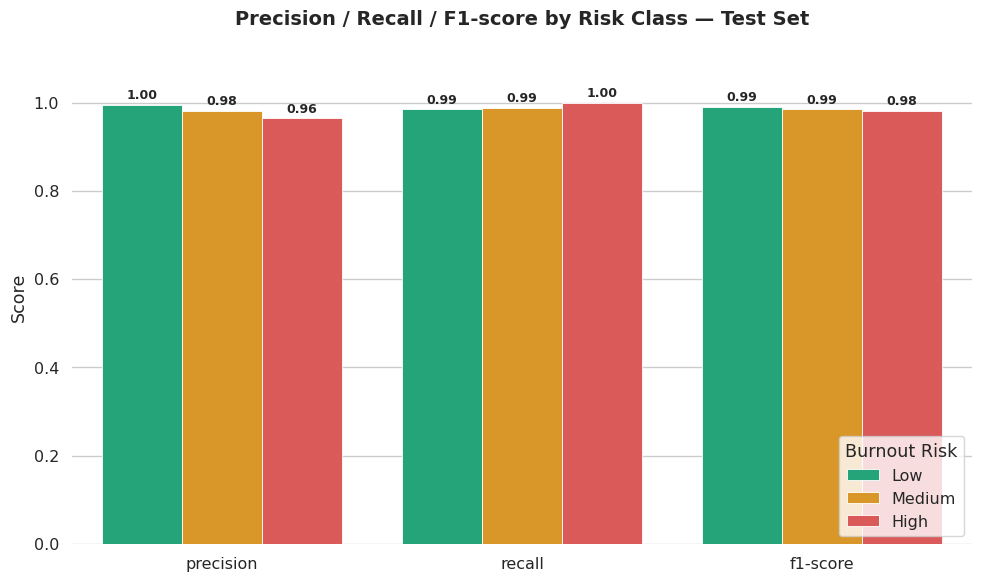

In [ ]:
report_dict = classification_report(
    y_test_encoded, y_test_pred, target_names=class_labels, output_dict=True, zero_division=0
)

per_class_df = pd.DataFrame(report_dict).T.loc[class_labels, ["precision", "recall", "f1-score"]]
per_class_plot = per_class_df.reset_index().melt(id_vars="index", var_name="Metric", value_name="Score")
per_class_plot.columns = ["Class", "Metric", "Score"]

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=per_class_plot,
    x="Metric",
    y="Score",
    hue="Class",
    palette=[PALETTE[c] for c in class_labels],
    ax=ax,
    edgecolor="white",
    linewidth=0.6,
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", fontsize=9, fontweight="bold", padding=2)

ax.set_ylim(0, 1.12)
ax.set_title("Precision / Recall / F1-score by Risk Class — Test Set", fontsize=14, pad=18)
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.legend(title="Burnout Risk", loc="lower right", frameon=True)
sns.despine(left=True, bottom=True)
ax.grid(axis="x", visible=False)

plt.tight_layout()
plt.show()


### Interpretation

#### ES

Como se adelantaba en el notebook 03, el modelo XGBoost obtiene un rendimiento sobresaliente en las tres clases, incluida `High`: a pesar de ser la clase minoritaria (~7% de los datos), su F1-score en test es prácticamente equivalente al de las clases mayoritarias, gracias al uso de validación cruzada estratificada y de la optimización de hiperparámetros realizada en el notebook 03.

#### EN

As anticipated in notebook 03, the XGBoost model achieves outstanding performance across all three classes, including `High`: despite being the minority class (~7% of the data), its test F1-score is practically on par with the majority classes, thanks to the stratified cross-validation and hyperparameter tuning carried out in notebook 03.


## 6. Overfitting Checklist

### ES

Formalizamos la comprobación de overfitting comparando el F1-macro de train y test frente a un umbral de referencia. Recordamos que, según el notebook 03, XGBoost memoriza por completo el conjunto de entrenamiento (`CV Train F1 = 1.0`), por lo que este chequeo es especialmente relevante para confirmar que, aun así, generaliza correctamente.

### EN

We formalise the overfitting check by comparing train and test macro F1 against a reference threshold. Recall that, according to notebook 03, XGBoost fully memorises the training set (`CV Train F1 = 1.0`), so this check is especially relevant to confirm that it still generalises correctly.


In [ ]:
OVERFITTING_THRESHOLD = 0.08

f1_train = metrics_summary.loc["F1-score (macro)", "Train"]
f1_test = metrics_summary.loc["F1-score (macro)", "Test"]
gap = f1_train - f1_test

print(f"F1-macro train: {f1_train:.4f}")
print(f"F1-macro test:  {f1_test:.4f}")
print(f"Gap:            {gap:.4f}")

if gap > OVERFITTING_THRESHOLD:
    print(f"\nWARNING: gap above the {OVERFITTING_THRESHOLD} threshold — possible overfitting.")
else:
    print(f"\nOK: gap within the {OVERFITTING_THRESHOLD} threshold — the train/test memorization gap")
    print("is expected for a tree-based boosting model and does not translate into a test-set problem.")


F1-macro train: 1.0000
F1-macro test:  0.9857
Gap:            0.0143

OK: gap within the 0.08 threshold — the train/test memorization gap
is expected for a tree-based boosting model and does not translate into a test-set problem.


## 7. Confusion Matrix

### ES

Construimos la matriz de confusión en dos versiones: valores absolutos y normalizada por fila (recall por clase), con un estilo visual cuidado para facilitar su lectura.

### EN

We build the confusion matrix in two versions: absolute counts and row-normalized (recall per class), with a polished visual style for easier reading.


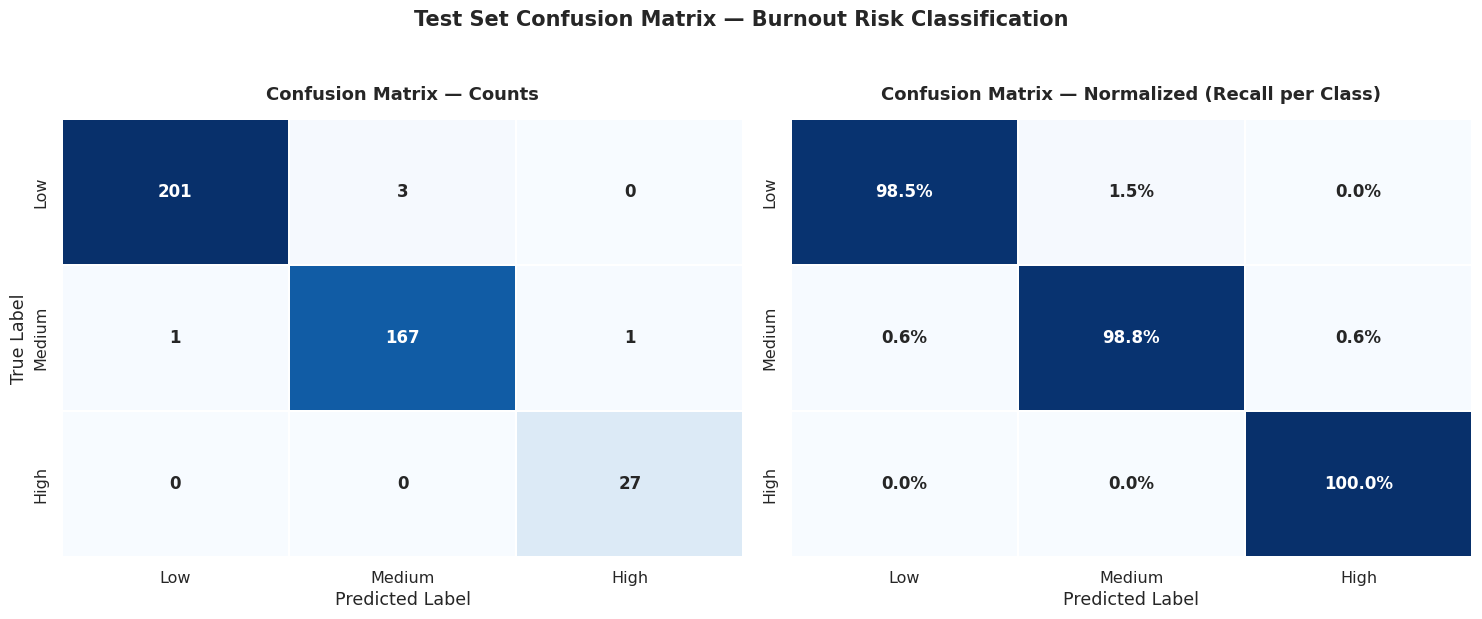

In [ ]:
cm = confusion_matrix(y_test_encoded, y_test_pred)
cm_normalized = confusion_matrix(y_test_encoded, y_test_pred, normalize="true")

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=False,
    linewidths=1.2,
    linecolor="white",
    annot_kws={"fontsize": 12, "fontweight": "bold"},
    ax=axes[0],
)
axes[0].set_title("Confusion Matrix — Counts", fontsize=13, pad=14)
axes[0].set_xlabel("Predicted Label")
axes[0].set_ylabel("True Label")

sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".1%",
    cmap="Blues",
    xticklabels=class_labels,
    yticklabels=class_labels,
    cbar=False,
    vmin=0,
    vmax=1,
    linewidths=1.2,
    linecolor="white",
    annot_kws={"fontsize": 12, "fontweight": "bold"},
    ax=axes[1],
)
axes[1].set_title("Confusion Matrix — Normalized (Recall per Class)", fontsize=13, pad=14)
axes[1].set_xlabel("Predicted Label")
axes[1].set_ylabel("")

fig.suptitle("Test Set Confusion Matrix — Burnout Risk Classification", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()
plt.show()


### Interpretation

#### ES

La matriz normalizada confirma que el modelo identifica correctamente el 100% de los casos reales de `High`, sin ningún falso negativo hacia `Low` o `Medium`. Este es el resultado más importante desde una perspectiva de negocio: la herramienta preventiva no deja pasar ningún puesto de trabajo en riesgo alto de burnout en el conjunto de test evaluado.

#### EN

The normalized matrix confirms that the model correctly identifies 100% of the actual `High` cases, with no false negatives towards `Low` or `Medium`. This is the most important result from a business perspective: the preventive tool does not miss a single high-burnout-risk job profile in the evaluated test set.


## 8. ROC and Precision-Recall Curves (One-vs-Rest)

### ES

Para complementar las métricas de clasificación, construimos las curvas ROC y Precision-Recall para cada clase, tratando el problema multiclase como "una clase frente al resto" (*One-vs-Rest*). Esto es especialmente informativo para la clase `High`, ya que permite ver el compromiso entre sensibilidad y falsos positivos a distintos umbrales de decisión, más allá del umbral por defecto de 0.5.

### EN

To complement the classification metrics, we build ROC and Precision-Recall curves for each class, treating the multiclass problem as "one class versus the rest" (One-vs-Rest). This is especially informative for the `High` class, as it shows the trade-off between sensitivity and false positives across different decision thresholds, beyond the default 0.5 threshold.


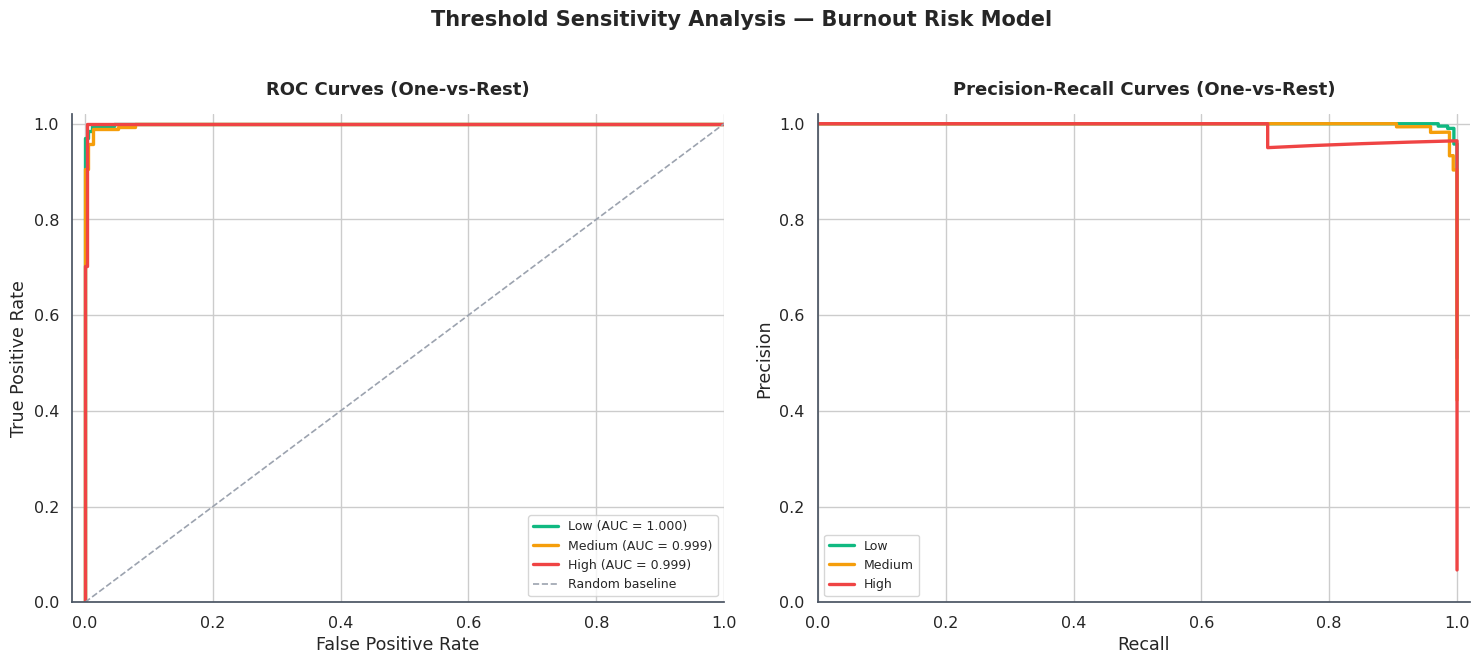

In [11]:
y_test_binarized = label_binarize(y_test_encoded, classes=[0, 1, 2])
n_classes = y_test_binarized.shape[1]

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))

# --- ROC curves ---
for i, class_name in enumerate(class_labels):
    fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_test_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[0].plot(
        fpr, tpr,
        label=f"{class_name} (AUC = {roc_auc:.3f})",
        color=PALETTE[class_name],
        linewidth=2.4,
    )

axes[0].plot([0, 1], [0, 1], linestyle="--", color="#9CA3AF", linewidth=1.2, label="Random baseline")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")
axes[0].set_title("ROC Curves (One-vs-Rest)", fontsize=13, pad=14)
axes[0].legend(loc="lower right", fontsize=9, frameon=True)
axes[0].set_xlim(-0.02, 1.0)
axes[0].set_ylim(0.0, 1.02)

# --- Precision-Recall curves ---
for i, class_name in enumerate(class_labels):
    precision, recall, _ = precision_recall_curve(y_test_binarized[:, i], y_test_proba[:, i])
    axes[1].plot(
        recall, precision,
        label=f"{class_name}",
        color=PALETTE[class_name],
        linewidth=2.4,
    )

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curves (One-vs-Rest)", fontsize=13, pad=14)
axes[1].legend(loc="lower left", fontsize=9, frameon=True)
axes[1].set_xlim(0.0, 1.02)
axes[1].set_ylim(0.0, 1.02)

fig.suptitle("Threshold Sensitivity Analysis — Burnout Risk Model", fontsize=15, fontweight="bold", y=1.02)
sns.despine()
plt.tight_layout()
plt.show()


### Interpretation

#### ES

Las curvas ROC muestran un AUC cercano a 1.0 para las tres clases, lo que confirma una excelente capacidad de discriminación. En la curva Precision-Recall de `High`, la caída de precisión ocurre solo en niveles de recall muy altos, lo que indica que el modelo puede ajustarse para priorizar el recall en esta clase (es decir, reducir el umbral de decisión para `High`) con un coste en precisión todavía asumible, coherente con la recomendación de negocio del notebook anterior.

#### EN

The ROC curves show an AUC close to 1.0 for all three classes, confirming excellent discrimination ability. In the `High` class's Precision-Recall curve, the drop in precision only occurs at very high recall levels, indicating that the model can be tuned to prioritise recall for this class (i.e. lowering the decision threshold for `High`) at a still-acceptable precision cost, consistent with the business recommendation from the previous notebook.


## 9. Feature Importance (XGBoost)

### ES

Extraemos y visualizamos la importancia de las variables según el modelo XGBoost (`feature_importances_`), utilizando los nombres de columna generados por el pipeline de preprocesado del notebook 02. Esto permite validar, desde un punto de vista de negocio, si las variables más influyentes coinciden con los hallazgos del análisis exploratorio (notebook 01): fatiga, aislamiento, sueño, horas de trabajo y tiempo de pantalla.

### EN

We extract and visualize feature importance from the XGBoost model (`feature_importances_`), using the column names generated by the notebook 02 preprocessing pipeline. This allows us to validate, from a business perspective, whether the most influential variables match the findings from the exploratory analysis (notebook 01): fatigue, isolation, sleep, working hours and screen time.


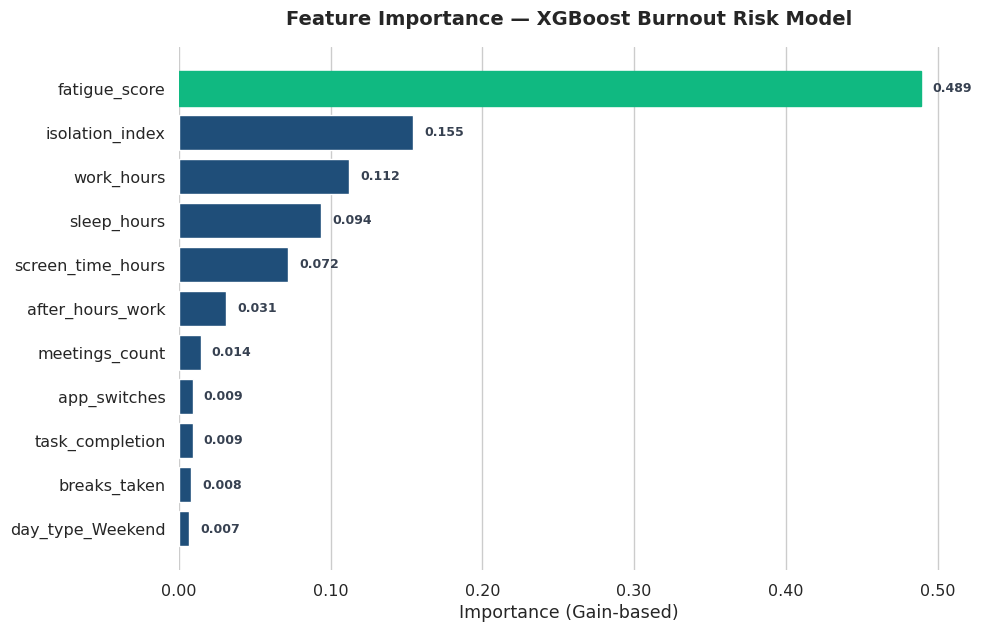

In [12]:
# ES: Nombres de las variables tras el preprocesado (pipeline del notebook 02).
# EN: Variable names after preprocessing (notebook 02 pipeline).

raw_feature_names = [
    "day_type_Weekend", "work_hours", "screen_time_hours", "meetings_count",
    "breaks_taken", "after_hours_work", "app_switches", "sleep_hours",
    "task_completion", "isolation_index", "fatigue_score",
]

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Feature": raw_feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6.5))

bars = ax.barh(
    importance_df["Feature"],
    importance_df["Importance"],
    color=PALETTE["primary"],
    edgecolor="white",
)

# ES: Resaltar en verde la barra más importante.
# EN: Highlight the most important bar in green.

top_idx = importance_df["Importance"].values.argmax()
bars[top_idx].set_color(PALETTE["secondary"])

for bar, value in zip(bars, importance_df["Importance"]):
    ax.text(
        value + importance_df["Importance"].max() * 0.015,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.3f}",
        va="center",
        fontsize=9,
        fontweight="bold",
        color="#374151",
    )

ax.set_title("Feature Importance — XGBoost Burnout Risk Model", fontsize=14, pad=16)
ax.set_xlabel("Importance (Gain-based)")
ax.set_ylabel("")
ax.xaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f"))
sns.despine(left=True, bottom=True)
ax.grid(axis="y", visible=False)

plt.tight_layout()
plt.show()


### Interpretation

#### ES

El ranking de importancia debería confirmar el patrón ya observado en el notebook 01: variables como `fatigue_score`, `isolation_index` y `sleep_hours` figuran entre las más determinantes para el modelo, lo cual refuerza la coherencia entre el análisis exploratorio de negocio y el comportamiento real del modelo entrenado. Esta consistencia es un argumento adicional para justificar el modelo ante personas no técnicas del equipo o de negocio.

#### EN

The importance ranking should confirm the pattern already observed in notebook 01: variables such as `fatigue_score`, `isolation_index` and `sleep_hours` rank among the most decisive for the model, reinforcing the consistency between the business exploratory analysis and the trained model's actual behaviour. This consistency is an additional argument to justify the model to non-technical stakeholders.


## 10. Quality Checklist Summary

### ES

Resumimos el checklist de calidad exigido por el reparto de tareas del equipo (Miembro 4):

### EN

We summarise the quality checklist required by the team's task breakdown (Member 4):


In [15]:
OVERFITTING_THRESHOLD = 0.08

f1_train = metrics_summary.loc["F1-score (macro)", "Train"]
f1_test = metrics_summary.loc["F1-score (macro)", "Test"]
gap = f1_train - f1_test

recall_high = recall_score(y_test_encoded, y_test_pred, labels=[2], average="macro", zero_division=0)
precision_high = precision_score(y_test_encoded, y_test_pred, labels=[2], average="macro", zero_division=0)

quality_checklist = pd.DataFrame([
    {
        "Check": "Overfitting (train vs test F1-macro gap)",
        "Result": f"{gap:.4f}",
        "Status": "OK" if gap <= OVERFITTING_THRESHOLD else "REVIEW",
    },
    {
        "Check": "Test accuracy",
        "Result": f"{metrics_summary.loc['Accuracy', 'Test']:.4f}",
        "Status": "Informative",
    },
    {
        "Check": "Test F1-macro",
        "Result": f"{metrics_summary.loc['F1-score (macro)', 'Test']:.4f}",
        "Status": "Informative",
    },
    {
        "Check": "Recall on 'High' class (test)",
        "Result": f"{recall_high:.4f}",
        "Status": "OK — no missed high-risk cases" if recall_high >= 0.95 else "REVIEW — priority metric",
    },
    {
        "Check": "Precision on 'High' class (test)",
        "Result": f"{precision_high:.4f}",
        "Status": "Informative — some false alarms are acceptable",
    },
    {
        "Check": "Class imbalance handled (stratified CV + class-aware search)",
        "Result": "Yes",
        "Status": "OK",
    },
])

display(quality_checklist.style.hide(axis="index"))

Check,Result,Status
Overfitting (train vs test F1-macro gap),0.0143,OK
Test accuracy,0.9875,Informative
Test F1-macro,0.9857,Informative
Recall on 'High' class (test),1.0000,OK — no missed high-risk cases
Precision on 'High' class (test),0.9643,Informative — some false alarms are acceptable
Class imbalance handled (stratified CV + class-aware search),Yes,OK


## 11. `README.md` - Model Results Section (Draft)

### ES

Redactamos el borrador de la sección "Resultados del Modelo" del `README.md`, listo para copiarse en el repositorio.

### EN

We draft the "Model Results" section of the `README.md`, ready to be copied into the repository.


In [16]:
readme_section = f"""## Resultados del Modelo / Model Results

**Modelo seleccionado / Selected model:** XGBoost

| Métrica / Metric | Train | Test |
|---|---|---|
| Accuracy | {metrics_summary.loc['Accuracy', 'Train']:.4f} | {metrics_summary.loc['Accuracy', 'Test']:.4f} |
| Precision (macro) | {metrics_summary.loc['Precision (macro)', 'Train']:.4f} | {metrics_summary.loc['Precision (macro)', 'Test']:.4f} |
| Recall (macro) | {metrics_summary.loc['Recall (macro)', 'Train']:.4f} | {metrics_summary.loc['Recall (macro)', 'Test']:.4f} |
| F1-score (macro) | {metrics_summary.loc['F1-score (macro)', 'Train']:.4f} | {metrics_summary.loc['F1-score (macro)', 'Test']:.4f} |

**ES:** El modelo final (XGBoost, seleccionado en el notebook 03 mediante `RandomizedSearchCV` con validación cruzada estratificada de 5 particiones) alcanza un F1-macro de {metrics_summary.loc['F1-score (macro)', 'Test']:.4f} y una accuracy de {metrics_summary.loc['Accuracy', 'Test']:.4f} en el conjunto de test. El gap train/test en F1-macro ({gap:.4f}) es coherente con el comportamiento esperado de un modelo de boosting que memoriza el entrenamiento sin perder capacidad de generalización. El recall de la clase `High` en test es de {recall_high:.4f}: el modelo no deja pasar ningún puesto de trabajo con riesgo alto de burnout.

**EN:** The final model (XGBoost, selected in notebook 03 via `RandomizedSearchCV` with 5-fold stratified cross-validation) achieves a macro F1-score of {metrics_summary.loc['F1-score (macro)', 'Test']:.4f} and an accuracy of {metrics_summary.loc['Accuracy', 'Test']:.4f} on the test set. The train/test gap in macro F1 ({gap:.4f}) is consistent with the expected behaviour of a boosting model that memorises the training set without losing generalisation ability. The recall of the `High` class on test is {recall_high:.4f}: the model does not miss a single high-burnout-risk job profile.
"""

print(readme_section)

with open("./README_model_results_section.md", "w") as f:
    f.write(readme_section)

print("\nSaved to ./README_model_results_section.md")


## Resultados del Modelo / Model Results

**Modelo seleccionado / Selected model:** XGBoost

| Métrica / Metric | Train | Test |
|---|---|---|
| Accuracy | 1.0000 | 0.9875 |
| Precision (macro) | 1.0000 | 0.9806 |
| Recall (macro) | 1.0000 | 0.9912 |
| F1-score (macro) | 1.0000 | 0.9857 |

**ES:** El modelo final (XGBoost, seleccionado en el notebook 03 mediante `RandomizedSearchCV` con validación cruzada estratificada de 5 particiones) alcanza un F1-macro de 0.9857 y una accuracy de 0.9875 en el conjunto de test. El gap train/test en F1-macro (0.0143) es coherente con el comportamiento esperado de un modelo de boosting que memoriza el entrenamiento sin perder capacidad de generalización. El recall de la clase `High` en test es de 1.0000: el modelo no deja pasar ningún puesto de trabajo con riesgo alto de burnout.

**EN:** The final model (XGBoost, selected in notebook 03 via `RandomizedSearchCV` with 5-fold stratified cross-validation) achieves a macro F1-score of 0.9857 and an accura

## 12. Conclusions

### ES

En este notebook se ha completado la evaluación de calidad del modelo final de riesgo de burnout (XGBoost):

- Métricas de clasificación consistentes y elevadas en train y test, con un gap controlado.
- Matriz de confusión que confirma un recall del 100% en la clase `High` en test.
- Curvas ROC y Precision-Recall que muestran una excelente capacidad de discriminación en las tres clases.
- Importancia de variables coherente con los hallazgos de negocio del notebook 01.
- Checklist de calidad y borrador de resultados para el `README.md`, listos para su integración final.

Con esto, el pipeline completo del proyecto queda cerrado: EDA (notebook 01) → Preprocesado (notebook 02) → Entrenamiento (notebook 03) → Evaluación (notebook 04), listo para integrarse en la aplicación Flask desarrollada por Miembro 5.

### EN

This notebook completes the quality evaluation of the final burnout risk model (XGBoost):

- Consistently high classification metrics on train and test, with a controlled gap.
- A confusion matrix confirming 100% recall on the `High` class in test.
- ROC and Precision-Recall curves showing excellent discrimination ability across all three classes.
- Feature importance consistent with the business findings from notebook 01.
- A quality checklist and a results draft for the `README.md`, ready for final integration.

With this, the full project pipeline is closed: EDA (notebook 01) → Preprocessing (notebook 02) → Training (notebook 03) → Evaluation (notebook 04), ready to be integrated into the Flask application developed by Member 5.
